# Module 2: Epidemic Modeling Template

## Team Members:
*Isabella Orlando and Hayden Rue*

## Project Title:
*(Fill in)*

## Project Goal:
This project seeks to... *(what is the purpose of your project -- i.e., describe the question that you seek to answer by analyzing data.)*

## 1. Data and disease background
You can fill out this section throughout the module as you uncover more information about the mystery disease.

By the end of the module (when submitting), you should have some information about each of the following points:
* Prevalence & incidence in the UVA population
* Economic burden (you can generalize from respiratory viruses)
* Symptoms
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

This project used a combination of exponential growth and SEIR  modeling to analyze and predict the trajectory of a mystery virus outbreak in a population of 17,900 people. Early stage data (through day 45) was fit to an exponential curve to estimate the initial growth rate (R0). The SEIR model was then solved numerically using Euler's method with a daily time step, dividing the population into Susceptible, Exposed, Infectious, and Recovered compartments. Model parameters (β, γ, σ) were then optimized by minimizing the sum of squared error (SSE) between the model output and observed active case counts via grid search. The fitted model was then projected forward to predict the peak day and total active cases of the outbreak, and later validated against the full dataset released in data release #3


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)
This section should come from your python code after Data Release #1.

In [1]:
#%%
import pandas as pd
import matplotlib.pyplot as plt

#%%
# Read the data
df = pd.read_csv(r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

#%%
# Create and label a plot of the active cases over time
plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Day vs Active Infections')
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\isabe\\OneDrive\\Documents\\BME2315\\Module-2-Epidemics-SIR-Modeling\\Data\\mystery_virus_daily_active_counts_RELEASE#1.csv'

* The initial number of infections is small but begins to increase rapidly around 25 days. The curve of the graph suggest exponential growth because as the number of infected individuals increases so does the total number of new infections.
* We could measure how quickly the virus is spreading through the growth rate, doubling time, and an average number of people one person can infect to determine how quickly it is spreading
* Knowing how contagious the virus is, population size, presence of immunity, and the length of infectious period, both symptomatic and asymptomatic, will be helpful in determining an outbreak curve.

Estimated r: 0.131365895627797
Estimated I0: 0.7111198627565817
Estimated R0: 1.9286677472085472


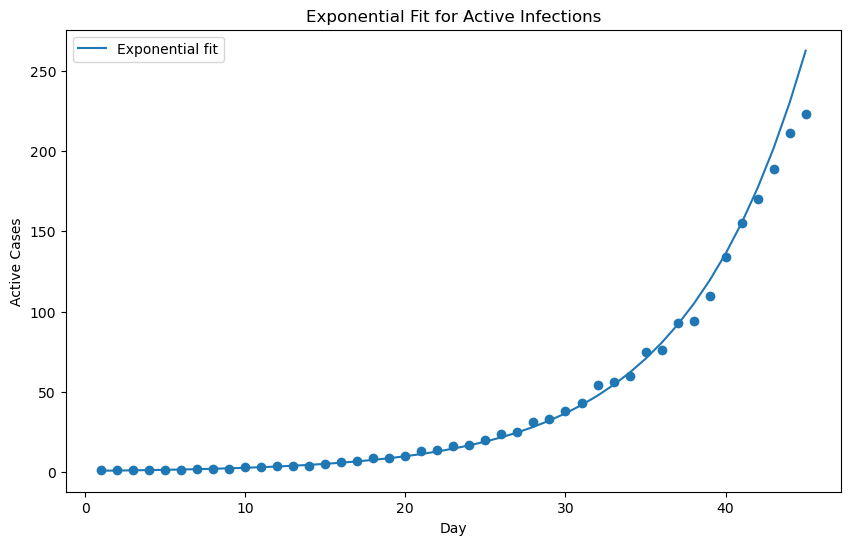

In [ ]:
#%%
import pandas as pd
import matplotlib.pyplot as plt

#%%
# Read the data
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv", parse_dates=['date'], header=0, index_col=None)

import numpy as np

#Get values from variables in csv
t = df["day"].values
I = df["active reported daily cases"].values

#only examine first 45 days for early exponential growth
mask = t <= 45
t_exp = t[mask]
I_exp = I[mask]

#%%
#linearize to use polyfit and get r from slope

# Remove zeros before log
positive_mask = I_exp > 0
t_fit = t_exp[positive_mask]
I_fit = I_exp[positive_mask]

log_I = np.log(I_fit)

# Linear regression
coeffs = np.polyfit(t_fit, log_I, 1)
r = coeffs[0]
log_I0 = coeffs[1]
I0 = np.exp(log_I0)

# print growth rate and estimated initial infections
print("Estimated r:", r)
print("Estimated I0:", I0)

#%%
#Estimate R0

D = 5
R0 = np.exp(r * D)

print("Estimated R0:", R0)


#%%
# Create and label a plot of the active cases over time with exponential fit for growth rate

I_model = I0 * np.exp(r * t)

#Plot
plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.plot(t, I_model, label = "Exponential fit")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Exponential Fit for Active Infections')
plt.legend()
plt.show()

Due to the exponential nature of the data, an exponential fit was used to determine the R0 value and represent the early growth rate of the virus. The data was linearized using a logarithmic function to perform the fit. The Estimated R0 value was 1.9286677472085472, signifing that approximately 2 people will become infected for every person infected through this early stage of the outbreak. The R0 estimate value is likely accurate since the data strongly resembles an expoenetial curve.


To help predict the trend of the data beyond day 45, we can compare the R0 from the mystery virus to other known R0s. Ebola and EV-D68 are viruses that have similar R0s around 2.

Ebola is an often fatal virus that results in hemorrhagic illness. It is believed to come from fruit bats with periodic outbreaks present in Central and West Africa.

EV-D68 is a virus that causes respiratory illness, ranging from mild to severe depending on the susceptibility of the person infected. The virus was originally rare, however outbreaks have increased and are showing symptoms related to neurological conditions and muscle weakness


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
This section should come from your python code after Data Release #2.

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)


### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
To fit the SEIR model to the data from release #2, a grid search optimization of the parameteres β, σ, and γ was performed. To inform the parameter ranges used for the search, the R0 estimate was used from the early exponential data since R0 = β/γ.

Search ranges:

* β: 0.1 to 0.5 (10 values)
* γ: 0.05 to 0.2 (10 values)
* σ: 0.1 to 0.5 (10 values)

For each set of parameters, Euler's method was run and the resulting output was compared to active cases using the sum of squared error(SSE). The combinations that minimized SSE were determined to be optimal.

Optimal values:

β = 0.5
γ = 0.2
σ ≈ 0.322

This gives a new fitted R0 of 2.5, which is relatively consistent with the early-stage estimate of 1.93. The discrepancy is caused by the inclusion of σ in the SEIR model, where the initial estimate used e^(r*D), where D was assumed to be 5 days. If the true infectious period differs from 5, the initial R0 estimate will be directly effected. Also, the esponential fit only used data through day 45, whereas the SEIR model was able to take data through day 70, improving its accuracy.


In [ ]:
# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

Optimal Beta: 0.5
Optimal Sigma: 0.32222222222222224
Optimal Gamma: 0.2
Optimal SSE: 139513.53806278316


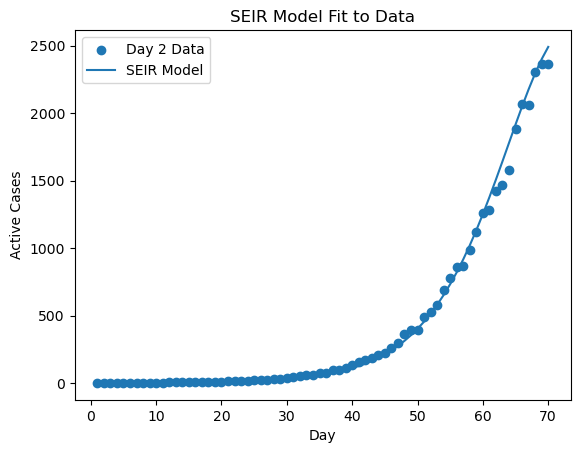

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)

# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

#Plot the model vs given data
plt.figure()
plt.scatter(day, active, label ="Day 2 Data")
plt.plot(day, I_best[:len(day)], label ="SEIR Model")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("SEIR Model Fit to Data")
plt.legend()
plt.show()



### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


Optimal Beta: 0.5
Optimal Sigma: 0.32222222222222224
Optimal Gamma: 0.2
Optimal SSE: 139513.53806278316
Peak infections: 2651.858284444435
Peak occurs on day: 73


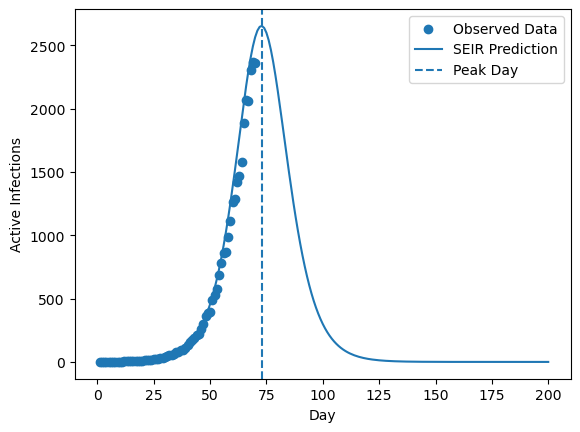

In [ ]:
#%%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data from csv file
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)

# Optimzation (grid search)
# Use estimated R0 to make an estimate for beta and gamma. R0 = 1.93 so beta = 1.93 * gamma
beta_values = np.linspace(0.1,0.5,10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

#Grid search to obtain optimal parameters
optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

#Find lowest sse by running eulers method for each parameter
for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            I_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) **2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

#Run model using new optimal parameters
I_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

#Predict future trends
future_days = 200

#Run eulers method on future days and find peak infections and peak day
I_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days)
peak_infections = np.max(I_future)
peak_day = np.argmax(I_future)
print("Peak infections:", peak_infections)
print("Peak occurs on day:", peak_day)

plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(range(len(I_future)), I_future, label="SEIR Prediction")
plt.axvline(peak_day, linestyle="--", label="Peak Day")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.legend()
plt.show()

The peak number of active infections(2,652) occuring at day 73 is a resonable prediction considering the large population size of 17,900. This means about 15% of the population is infected on the peak, or 73rd day.


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


Our model shows ~12% relative error from the new data release(true values) for the day of peak cases and ~19.5% for the number of peak cases.

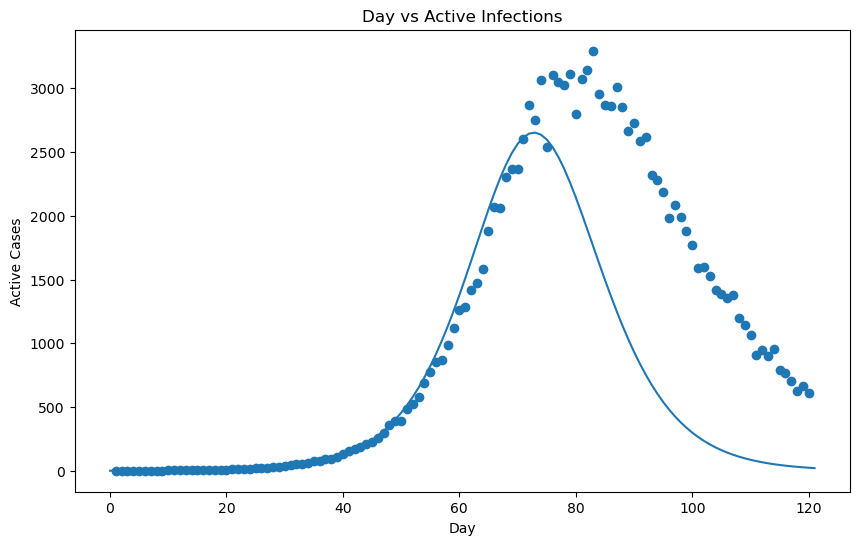

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

days = 121
N = 17900
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Load data from csv file
#df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv", parse_dates=['date'], header=0, index_col=None)
df = pd.read_csv(r"/Users/haydenrue/Desktop/Comp BME/Module 2/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv")
day = df["day"].values
active = df["active reported daily cases"].values

def run_euler(beta,sigma,gamma,total_days):
    S, E, I, R = [S0], [E0], [I0], [R0] #Initialize S,E,I,R as empty lists; set first item in list equal to initial values
    h = 1 #step size is 1 day

    for t in range(total_days):
        #Calculate derivatives from slide 6 class presentation
        dS = -(beta * S[t]* I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        #Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)
    return np.array(I)


optimal_beta = .5
optimal_gamma = .2
optimal_sigma = .32222222222

I_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, days)

plt.figure(figsize=(10, 6))
plt.scatter(df['day'], df['active reported daily cases'])
plt.plot(range(len(I_future)), I_future, label="SEIR Prediction")
plt.xlabel('Day')
plt.ylabel('Active Cases')
plt.title('Day vs Active Infections')
plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)




Optimal Beta: 0.4111111111111111
Optimal Sigma: 0.5
Optimal Gamma: 0.2
Optimal SSE: 15610107.112685319


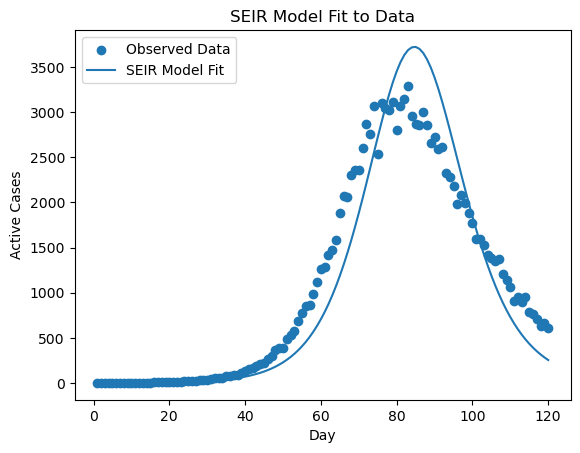

No intervention peak infections: 3721.9493474892183
No intervention peak day: 84
With vaccine peak infections: 3234.1259355773263
With vaccine peak day: 81


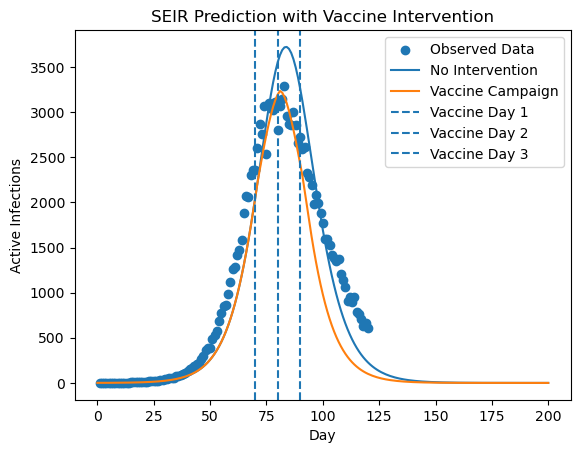

Optimal Beta: 0.4111111111111111
Optimal Sigma: 0.5
Optimal Gamma: 0.2
Optimal SSE: 15610107.112685319


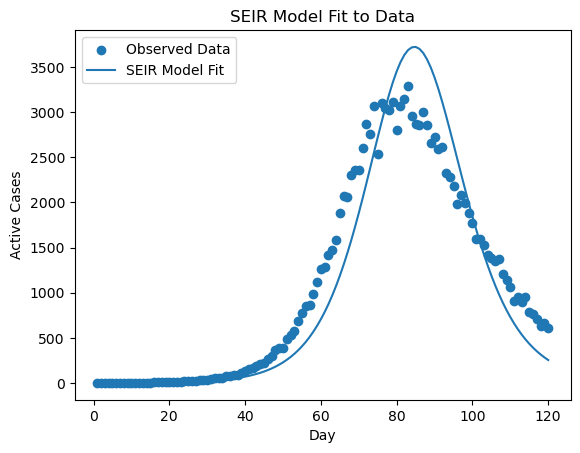

No intervention peak infections: 3721.9493474892183
No intervention peak day: 84
With vaccine peak infections: 3254.5155772337503
With vaccine peak day: 83


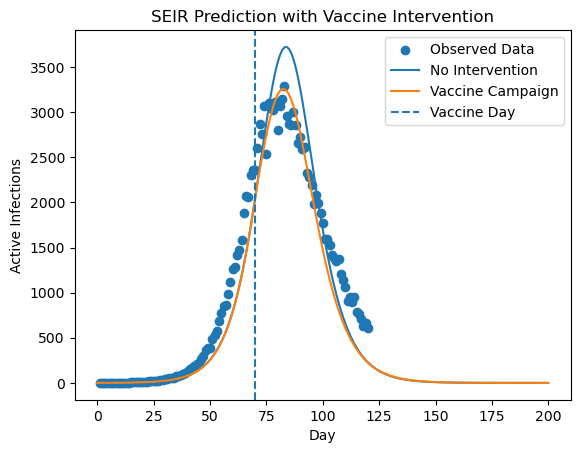

Peak infections with testing + quarantine: 2043.1756027809965
Peak occurs on day: 70


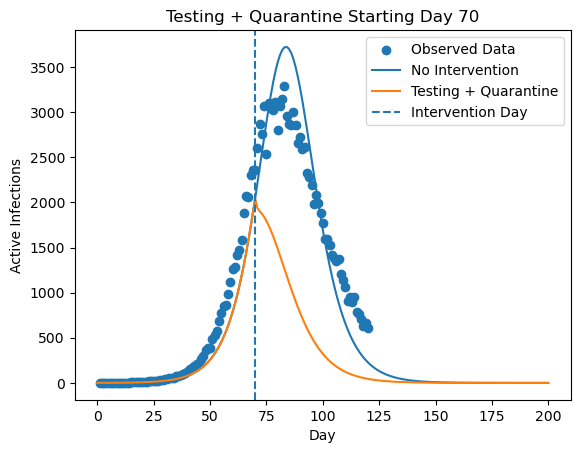

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Load data from csv file
df = pd.read_csv(r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-2-Epidemics-SIR-Modeling\Data\mystery_virus_daily_active_counts_RELEASE#3.csv")
day = df["day"].values
active = df["active reported daily cases"].values

# Set up variables
N = 31000
S0, E0, I0, R0 = N - 1, 0, 1, 0

def run_euler(beta, sigma, gamma, total_days, intervention=False):
    S, E, I, R = [S0], [E0], [I0], [R0]
    h = 1

    vaccine_day1 = 70
    vaccine_day2 = 80
    vaccine_day3 = 90
    vaccinated_students = 2000
    efficacy = 0.90
    effectively_vaccinated = vaccinated_students * efficacy  # 1800

    for t in range(total_days):
        # Vaccine campaign on day 70, 80, and 90
        if intervention and t in [vaccine_day1, vaccine_day2, vaccine_day3]:
            actual_vaccinated = min(S[t], effectively_vaccinated)
            S[t] = S[t] - actual_vaccinated
            R[t] = R[t] + actual_vaccinated

        # Derivatives
        dS = -(beta * S[t] * I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        # Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)

    return np.array(S), np.array(E), np.array(I), np.array(R)


# Optimization (grid search)
beta_values = np.linspace(0.1, 0.5, 10) # Transmission rate range 0.1 to 0.5
gamma_values = np.linspace(0.05, 0.2, 10) # Recovery rate 5 to 20 days
sigma_values = np.linspace(0.1, 0.5, 10) # Incubation rate 2 to 10 days

optimal_sse = np.inf # Initialize optimal sum of squared errors to infinity
optimal_beta = None # Initialize optimal beta to None
optimal_sigma = None 
optimal_gamma = None

total_days = len(day) # Total number of days in the dataset

for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            S_model, E_model, I_model, R_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)] # Ensure model predictions are the same length as observed data
            sse = np.sum((active - I_model) ** 2) # Calculate sum of squared errors between observed active cases and model predictions

            if sse < optimal_sse:
                optimal_sse = sse # Update optimal parameters if current sse is lower than the best found so far
                optimal_beta = beta # Update optimal beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

# Run model using optimal parameters
S_best, E_best, I_best, R_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days) # Run the SEIR model with the optimal parameters to get the best fit for S, E, I, R over time

# Plot model fit
plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(day, I_best[:len(day)], label="SEIR Model Fit")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("SEIR Model Fit to Data")
plt.legend()
plt.show()

# Predict future trends
future_days = 200 

# No intervention
S_future, E_future, I_future, R_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days, intervention=False) # Run the SEIR model for future predictions without intervention

# With vaccine campaign
S_vax, E_vax, I_vax, R_vax = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days, intervention=True) # Run the SEIR model for future predictions with the vaccine campaign intervention starting on day 60

# Peaks
peak_infections = np.max(I_future) # Find the maximum number of infections in the future predictions without intervention
peak_day = np.argmax(I_future) # Find the day on which the peak number of infections occurs in the future predictions without intervention

peak_infections_vax = np.max(I_vax)
peak_day_vax = np.argmax(I_vax)

print("No intervention peak infections:", peak_infections)
print("No intervention peak day:", peak_day)
print("With vaccine peak infections:", peak_infections_vax)
print("With vaccine peak day:", peak_day_vax)

# Plot future comparison
plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(range(len(I_future)), I_future, label="No Intervention")
plt.plot(range(len(I_vax)), I_vax, label="Vaccine Campaign")
plt.axvline(70, linestyle="--", label="Vaccine Day 1")
plt.axvline(80, linestyle="--", label="Vaccine Day 2")
plt.axvline(90, linestyle="--", label="Vaccine Day 3")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("SEIR Prediction with Vaccine Intervention")
plt.legend()
plt.show()

#%% 
#Intervention 2: Testing + quarantine starting on day 70, reducing infectious period by 2 days
# Set up variables
N = 31000
S0, E0, I0, R0 = N - 1, 0, 1, 0

# Euler function for SEIR
def run_euler(beta, sigma, gamma, total_days, intervention=False):
    S, E, I, R = [S0], [E0], [I0], [R0]
    h = 1

    vaccine_day = 70
    vaccinated_students = 2000
    efficacy = 0.90
    effectively_vaccinated = vaccinated_students * efficacy  # 1800

    for t in range(total_days):
        # Vaccine campaign on day 70
        if intervention and t == vaccine_day:
            actual_vaccinated = min(S[t], effectively_vaccinated)
            S[t] = S[t] - actual_vaccinated
            R[t] = R[t] + actual_vaccinated

        # Derivatives
        dS = -(beta * S[t] * I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (gamma * I[t])
        dR = (gamma * I[t])

        # Update values
        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)

    return np.array(S), np.array(E), np.array(I), np.array(R)

# Optimization (grid search)
beta_values = np.linspace(0.1, 0.5, 10)
gamma_values = np.linspace(0.05, 0.2, 10)
sigma_values = np.linspace(0.1, 0.5, 10)

optimal_sse = np.inf
optimal_beta = None
optimal_sigma = None
optimal_gamma = None

total_days = len(day)

for beta in beta_values:
    for sigma in sigma_values:
        for gamma in gamma_values:
            S_model, E_model, I_model, R_model = run_euler(beta, sigma, gamma, total_days)
            I_model = I_model[:len(active)]
            sse = np.sum((active - I_model) ** 2)

            if sse < optimal_sse:
                optimal_sse = sse
                optimal_beta = beta
                optimal_gamma = gamma
                optimal_sigma = sigma

print("Optimal Beta:", optimal_beta)
print("Optimal Sigma:", optimal_sigma)
print("Optimal Gamma:", optimal_gamma)
print("Optimal SSE:", optimal_sse)

# Run model using optimal parameters
S_best, E_best, I_best, R_best = run_euler(optimal_beta, optimal_sigma, optimal_gamma, total_days)

# Plot model fit
plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(day, I_best[:len(day)], label="SEIR Model Fit")
plt.xlabel("Day")
plt.ylabel("Active Cases")
plt.title("SEIR Model Fit to Data")
plt.legend()
plt.show()

# Predict future trends
future_days = 200

# No intervention
S_future, E_future, I_future, R_future = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days, intervention=False)

# With vaccine campaign
S_vax, E_vax, I_vax, R_vax = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days, intervention=True)

# Peaks
peak_infections = np.max(I_future)
peak_day = np.argmax(I_future)

peak_infections_vax = np.max(I_vax)
peak_day_vax = np.argmax(I_vax)

print("No intervention peak infections:", peak_infections)
print("No intervention peak day:", peak_day)
print("With vaccine peak infections:", peak_infections_vax)
print("With vaccine peak day:", peak_day_vax)

# Plot future comparison
plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(range(len(I_future)), I_future, label="No Intervention")
plt.plot(range(len(I_vax)), I_vax, label="Vaccine Campaign")
plt.axvline(70, linestyle="--", label="Vaccine Day")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("SEIR Prediction with Vaccine Intervention")
plt.legend()
plt.show()

#%%
#Intervention 3: Testing + quarantine starting on day 70, reducing infectious period by 2 day

def run_euler(beta, sigma, gamma, total_days, intervention_day=None):
    S, E, I, R = [S0], [E0], [I0], [R0]
    h = 1

    for t in range(total_days):
        current_gamma = gamma

        # Testing + quarantine starts on day 70
        if intervention_day is not None and t >= intervention_day:
            infectious_period = 1 / gamma
            new_infectious_period = infectious_period - 2

            if new_infectious_period <= 0:
                new_infectious_period = 0.1

            current_gamma = 1 / new_infectious_period

        dS = -(beta * S[t] * I[t]) / N
        dE = (beta * S[t] * I[t]) / N - (sigma * E[t])
        dI = (sigma * E[t]) - (current_gamma * I[t])
        dR = (current_gamma * I[t])

        S.append(S[t] + dS * h)
        E.append(E[t] + dE * h)
        I.append(I[t] + dI * h)
        R.append(R[t] + dR * h)

    return np.array(I)

future_days = 200

I_future_no_intervention = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days)
I_future_with_quarantine = run_euler(optimal_beta, optimal_sigma, optimal_gamma, future_days, intervention_day=70)

peak_infections = np.max(I_future_with_quarantine)
peak_day = np.argmax(I_future_with_quarantine)

print("Peak infections with testing + quarantine:", peak_infections)
print("Peak occurs on day:", peak_day)

plt.figure()
plt.scatter(day, active, label="Observed Data")
plt.plot(range(len(I_future_no_intervention)), I_future_no_intervention, label="No Intervention")
plt.plot(range(len(I_future_with_quarantine)), I_future_with_quarantine, label="Testing + Quarantine")
plt.axvline(70, linestyle="--", label="Intervention Day")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.title("Testing + Quarantine Starting Day 70")
plt.legend()
plt.show()

## Verify and validate your analysis: 

To verify that the SEIR model was implemented correctly, the model predictions were compared to the observed data from the dataset. A grid search was used to find the values of beta, sigma, and gamma that minimized the sum of squared error (SSE) between the model and the reported cases. The resulting infection curve closely followed the trend of the observed data, suggesting the model parameters were reasonable. Additional checks were performed by introducing interventions and confirming that vaccination and testing/quarantine reduced the peak number of infections compared to the no-intervention scenario. These results are consistent with prior knowledge of the effects of disease interventions, as well as published epidemiological studies showing that vaccination campaigns and reduced infectious periods from testing and quarantine can significantly limit disease spread.


## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*